In [31]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [32]:
df = pd.read_csv("/content/sample_data/income.csv")
df.head()

,Name,Age,Income
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


Text(0, 0.5, 'Income')

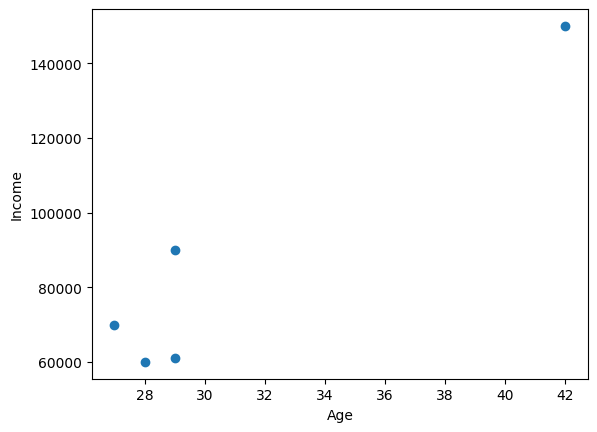

In [33]:
plt.scatter(df.Age,df['Income'])
plt.xlabel('Age')
plt.ylabel('Income')

In [34]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age','Income']])
y_predicted

array([0, 2, 0, 0, 1], dtype=int32)

In [35]:
df['cluster']=y_predicted
df.head()

,Name,Age,Income,cluster
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [36]:
km.cluster_centers_

array([[2.80000000e+01, 6.36666667e+04],
       [4.20000000e+01, 1.50000000e+05],
       [2.90000000e+01, 9.00000000e+04]])

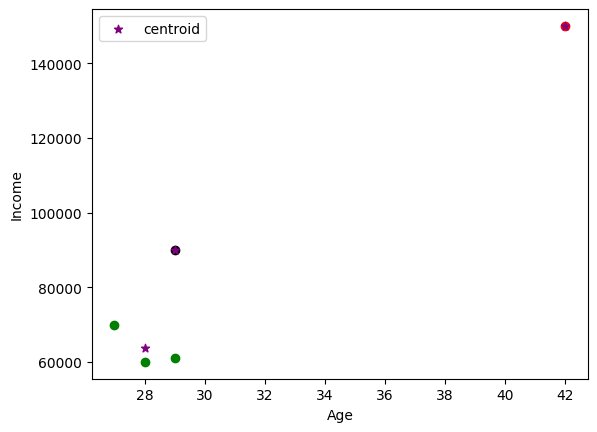

In [37]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Income'],color='green')
plt.scatter(df2.Age,df2['Income'],color='red')
plt.scatter(df3.Age,df3['Income'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()

In [38]:
#preprocessing using MINMAX
scaler = MinMaxScaler()

scaler.fit(df[['Income']])
df['Income'] = scaler.transform(df[['Income']])

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])
df.head()

,Name,Age,Income,cluster
0,Rob,0.000000,0.111111,0
1,Michael,0.133333,0.333333,2
2,Mohan,0.133333,0.011111,0
3,Ismail,0.066667,0.000000,0
4,Kory,1.000000,1.000000,1


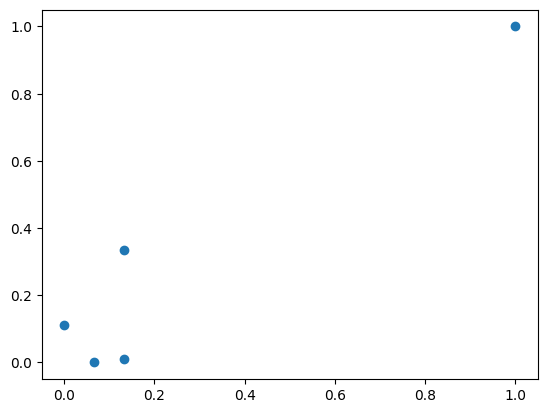

In [39]:
plt.scatter(df.Age,df['Income'])

In [40]:

km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age','Income']])
y_predicted

array([0, 2, 0, 0, 1], dtype=int32)

In [41]:
df['cluster']=y_predicted
df.head()

,Name,Age,Income,cluster
0,Rob,0.000000,0.111111,0
1,Michael,0.133333,0.333333,2
2,Mohan,0.133333,0.011111,0
3,Ismail,0.066667,0.000000,0
4,Kory,1.000000,1.000000,1


In [42]:
km.cluster_centers_

array([[0.06666667, 0.04074074],
       [1.        , 1.        ],
       [0.13333333, 0.33333333]])

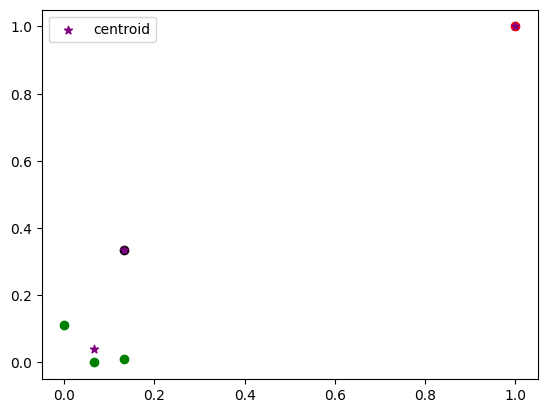

In [43]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Income'],color='green')
plt.scatter(df2.Age,df2['Income'],color='red')
plt.scatter(df3.Age,df3['Income'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

##Elbow Plot

In [48]:
sse = []        #Sum of Squared Errors
k_rng = range(1,len(df)+1)
for k in k_rng:
    km = KMeans(n_clusters=k, n_init=10)
    km.fit(df[['Age','Income']])
    sse.append(km.inertia_)

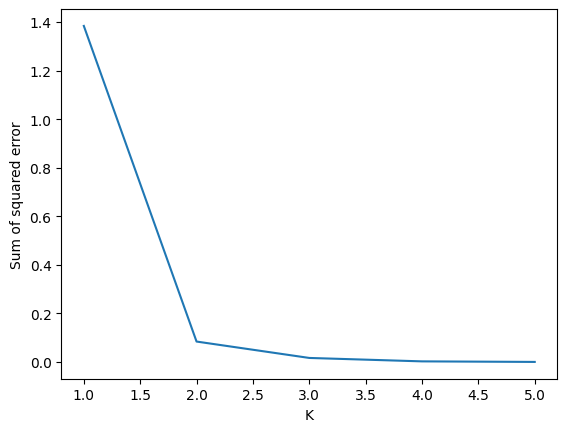

In [47]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)